# A simple example of quadratic estimator normalization calculation (general cases)
This code compute normalization of quadratic estiamtors

In [1]:
# external
import numpy as np, sys
from matplotlib.pyplot import *

In [2]:
# import tempura
import pytempura as tempura

First define parameters

In [3]:
Tcmb  = 2.726e6    # CMB temperature
Lmax  = 3000       # maximum multipole of output normalization
lmax  = 3000
rlmin, rlmax = 100, 3000  # CMB multipole range for reconstruction
L = np.linspace(0,Lmax,Lmax+1)
l = L.copy()
Lfac = (L*(L+1.))**2/(2*np.pi)

Load arrays of lensed CMB Cls. The Cls should not be multiplied by any factors and should not have units.  

In [4]:
lcl = np.zeros((4,lmax+1)) # TT, EE, BB, TE
lcl[:,2:] = np.loadtxt('data/lensedcls.dat',unpack=True,usecols=(1,2,3,4))[:,:lmax-1] 
lcl *= 2.*np.pi / (l**2+l+1e-30) / Tcmb**2

Define observed CMB cls. Here, no CMB noise.

In [5]:
ocl = lcl*1. # observed Cl (here, no CMB noise)

### Compute normalization (anisotropic birefringence)

QDO below specifies which normalizations will be computed: TT, TE, EE, TB, EB, BB (currently BB is ignored even if you set True)

MV is currently not automatically computed

In [6]:
QDO = [False,True,True,True,True,False]

In [7]:
Ar = tempura.norm_general.qall('rot',QDO,Lmax,rlmin,rlmax,lcl,lcl[0:4],ocl)[0]

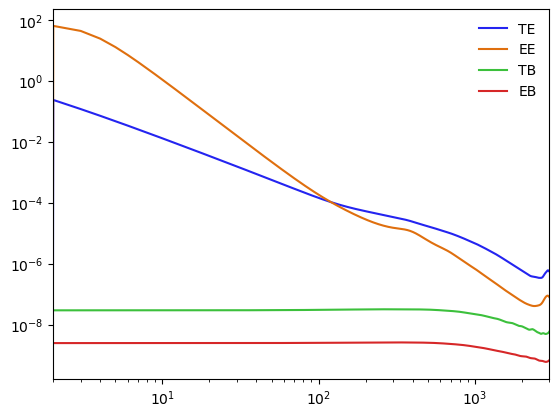

In [8]:
# plot spectra (anisotropic birefringence)
xlim(2,Lmax)
xscale('log')
yscale('log')
for i, q in enumerate(['TE','EE','TB','EB']):
    plot(L,Ar[i+1],label=q)
legend()

In [9]:
QDO = [True,True,True,True,True,False]

In [10]:
At = tempura.norm_general.qall('amp',QDO,Lmax,rlmin,rlmax,lcl,lcl[0:4],ocl)[0]

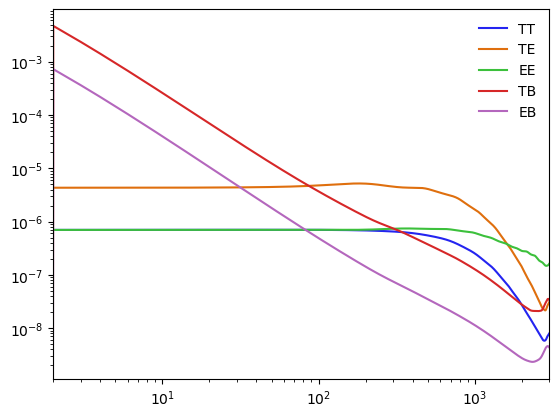

In [11]:
# plot spectra (anisotropic birefringence)
xlim(2,Lmax)
xscale('log')
yscale('log')
for i, q in enumerate(['TT','TE','EE','TB','EB']):
    plot(L,At[i],label=q)
legend()